# Análise Exploratória de Dados: Risco de Crédito

**Projeto:** Predição de inadimplência (Home Credit Default Risk)

**Dataset:** Home Credit Default Risk (Kaggle)

**Benchmark:** Yang et al. (2025) - *Interpretable Credit Default Prediction with Ensemble Learning and SHAP*

Este notebook realiza a análise exploratória dos dados, identificando características, anomalias e padrões que orientarão o pré-processamento e a modelagem.


## 1. Importação de bibliotecas e carregamento dos dados

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/application_train.csv')

print(f"Formato da tabela: {df.shape[0]} linhas e {df.shape[1]} colunas")

Formato da tabela: 307511 linhas e 122 colunas


## 2. Primeira visão dos dados

Inspeção inicial da estrutura da tabela: colunas, tipos e primeiros registros.

In [15]:

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 3. Análise da variável-alvo (TARGET)

A variável `TARGET` indica inadimplência: `0` = adimplente, `1` = inadimplente. Aqui avaliamos sua distribuição,ponto crítico, pois define o desafio de desbalanceamento do projeto.

In [17]:
print(df['TARGET'].value_counts())
print()
print("Em porcentagem:")
print(df['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64

Em porcentagem:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


## 4. Análise de valores faltantes

Identificação das colunas com dados ausentes e do percentual de ausência, fundamental para definir a estratégia de tratamento (descarte vs. imputação).

In [18]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df)) * 100

resumo_faltantes = pd.DataFrame({
    'Faltantes': faltantes,
    'Percentual (%)': faltantes_pct
})
resumo_faltantes = resumo_faltantes[resumo_faltantes['Faltantes'] > 0]
resumo_faltantes = resumo_faltantes.sort_values('Percentual (%)', ascending=False)

print(f"Colunas com valores faltantes: {len(resumo_faltantes)} de {df.shape[1]}")
print()
print("As 15 colunas com mais valores faltantes:")
resumo_faltantes.head(15)

Colunas com valores faltantes: 67 de 122

As 15 colunas com mais valores faltantes:


,Faltantes,Percentual (%)
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


## 5. Estatísticas descritivas

Resumo estatístico das principais variáveis numéricas, usado para detectar anomalias e outliers nos dados.

In [19]:
colunas_interesse = [
    'AMT_INCOME_TOTAL',   # renda total do cliente
    'AMT_CREDIT',         # valor do crédito solicitado
    'AMT_ANNUITY',        # valor da parcela (anuidade)
    'DAYS_BIRTH',         # idade (em dias negativos a partir de hoje)
    'DAYS_EMPLOYED',      # tempo de emprego (em dias negativos)
    'CNT_CHILDREN'        # número de filhos
]

df[colunas_interesse].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN
count,3.075110e+05,3.075110e+05,307499.000000,307511.000000,307511.000000,307511.000000
mean,1.687979e+05,5.990260e+05,27108.573909,-16036.995067,63815.045904,0.417052
std,2.371231e+05,4.024908e+05,14493.737315,4363.988632,141275.766519,0.722121
min,2.565000e+04,4.500000e+04,1615.500000,-25229.000000,-17912.000000,0.000000
25%,1.125000e+05,2.700000e+05,16524.000000,-19682.000000,-2760.000000,0.000000
50%,1.471500e+05,5.135310e+05,24903.000000,-15750.000000,-1213.000000,0.000000
75%,2.025000e+05,8.086500e+05,34596.000000,-12413.000000,-289.000000,1.000000
max,1.170000e+08,4.050000e+06,258025.500000,-7489.000000,365243.000000,19.000000


## 6. Visualizações

### 6.1 Distribuição da variável-alvo

Visualização do desbalanceamento entre adimplentes e inadimplentes.

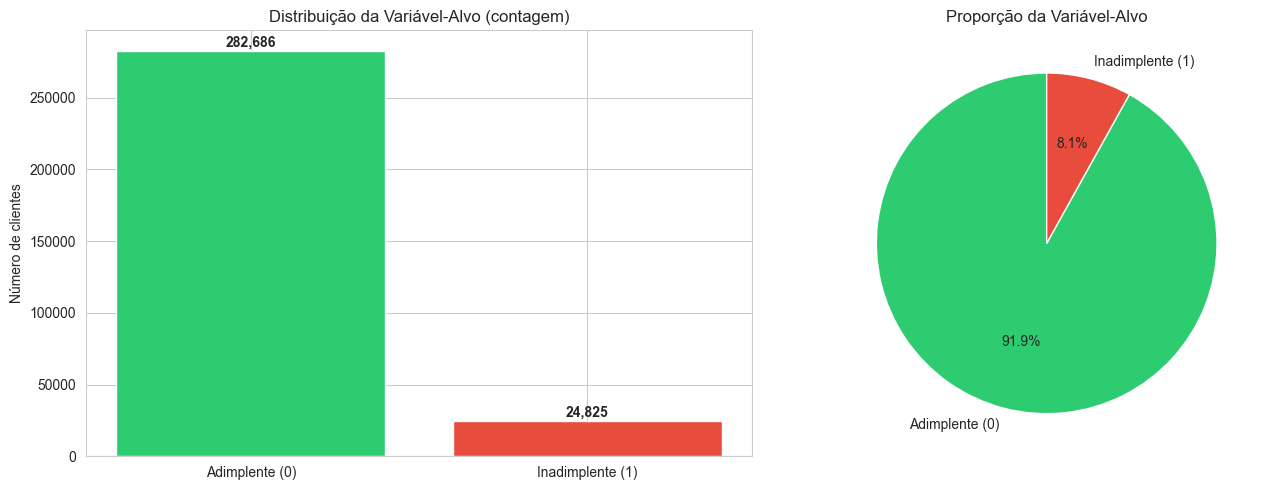

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras (contagem absoluta)
target_counts = df['TARGET'].value_counts()
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição da Variável-Alvo (contagem)', fontsize=12)
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pizza (proporção)
axes[1].pie(target_counts.values, labels=['Adimplente (0)', 'Inadimplente (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporção da Variável-Alvo', fontsize=12)

plt.tight_layout()
plt.show()

### 6.2 Idade vs. inadimplência

Conversão de `DAYS_BIRTH` em idade (anos) e análise da relação entre idade e risco de inadimplência por classe.

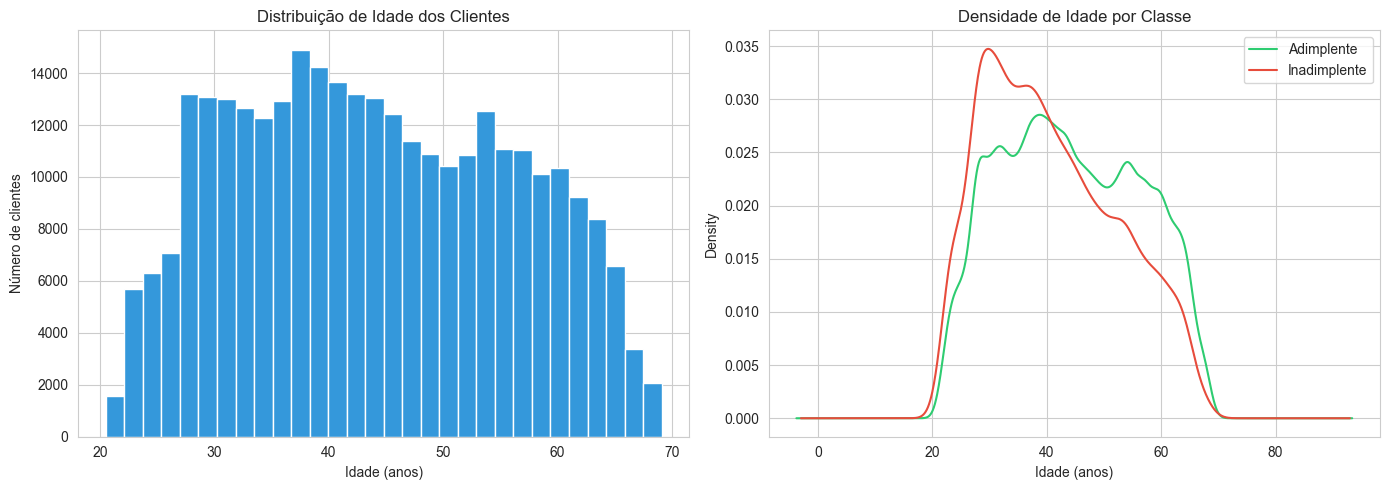

In [ ]:
# Converter DAYS_BIRTH (dias negativos) em anos
df['IDADE_ANOS'] = (-df['DAYS_BIRTH'] / 365).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral da idade
axes[0].hist(df['IDADE_ANOS'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Distribuição de Idade dos Clientes', fontsize=12)
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Número de clientes')

# Idade separada por classe (adimplente vs inadimplente)
df[df['TARGET'] == 0]['IDADE_ANOS'].plot(kind='kde', ax=axes[1],
                                          label='Adimplente', color='#2ecc71')
df[df['TARGET'] == 1]['IDADE_ANOS'].plot(kind='kde', ax=axes[1],
                                          label='Inadimplente', color='#e74c3c')
axes[1].set_title('Densidade de Idade por Classe', fontsize=12)
axes[1].set_xlabel('Idade (anos)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.3 Renda e crédito

Distribuição da renda (tratando outliers) e relação entre renda e valor do crédito, colorida por classe.

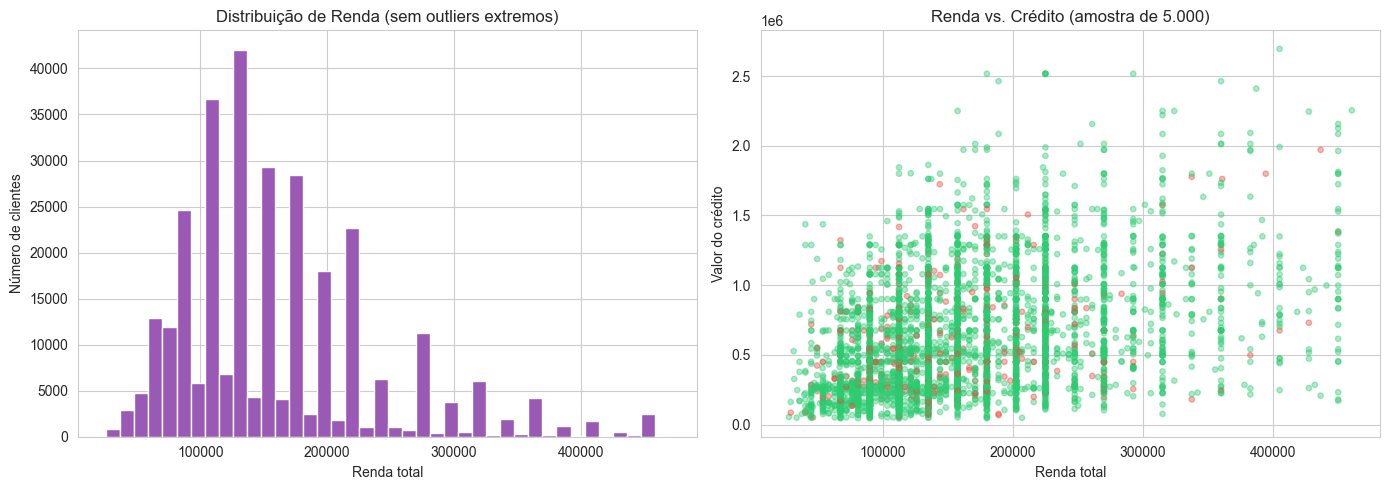

In [ ]:
# Usamos filtro para remover outliers extremos de renda e enxergar melhor o padrão
filtro = df['AMT_INCOME_TOTAL'] < df['AMT_INCOME_TOTAL'].quantile(0.99)
df_filtrado = df[filtro]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição da renda (sem o 1% de outliers extremos)
axes[0].hist(df_filtrado['AMT_INCOME_TOTAL'], bins=40,
             color='#9b59b6', edgecolor='white')
axes[0].set_title('Distribuição de Renda (sem outliers extremos)', fontsize=12)
axes[0].set_xlabel('Renda total')
axes[0].set_ylabel('Número de clientes')

# Relação renda x crédito, colorida por classe
amostra = df_filtrado.sample(5000, random_state=42)  # amostra para não pesar o gráfico
cores = amostra['TARGET'].map({0: '#2ecc71', 1: '#e74c3c'})
axes[1].scatter(amostra['AMT_INCOME_TOTAL'], amostra['AMT_CREDIT'],
                c=cores, alpha=0.4, s=15)
axes[1].set_title('Renda vs. Crédito (amostra de 5.000)', fontsize=12)
axes[1].set_xlabel('Renda total')
axes[1].set_ylabel('Valor do crédito')

plt.tight_layout()
plt.show()

### 6.4 Taxa de inadimplência por categorias

Análise da taxa de inadimplência segmentada por escolaridade e tipo de renda.

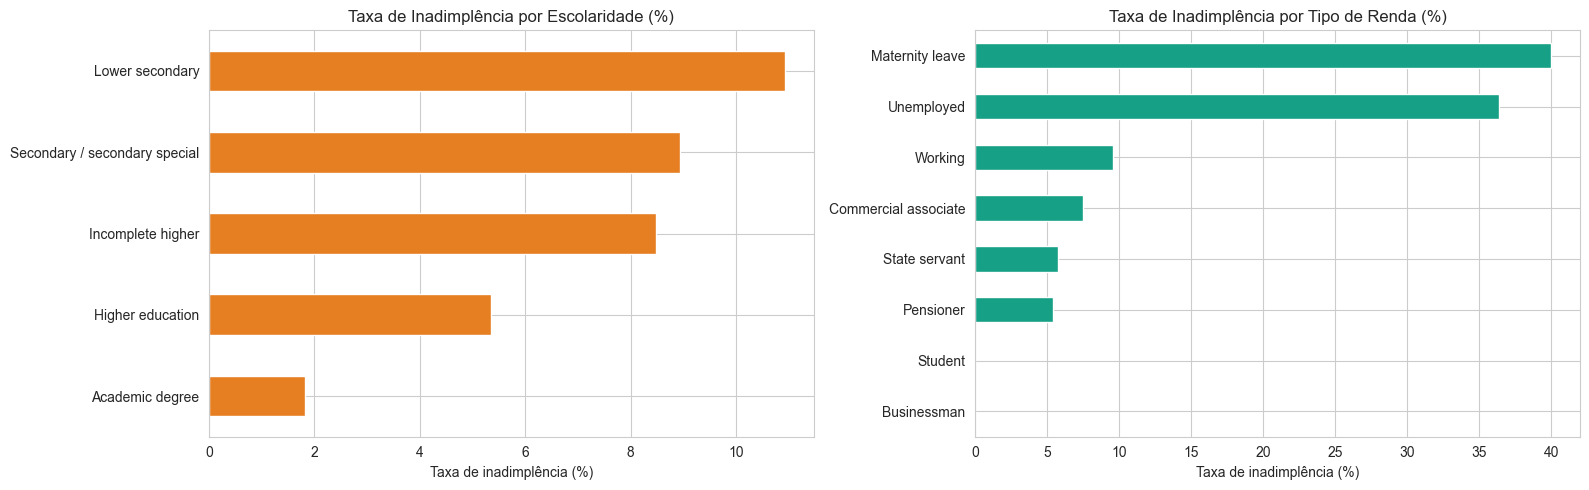

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Taxa de inadimplência por nível de educação
educ = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values() * 100
educ.plot(kind='barh', ax=axes[0], color='#e67e22')
axes[0].set_title('Taxa de Inadimplência por Escolaridade (%)', fontsize=12)
axes[0].set_xlabel('Taxa de inadimplência (%)')
axes[0].set_ylabel('')

# Taxa de inadimplência por tipo de renda
renda = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values() * 100
renda.plot(kind='barh', ax=axes[1], color='#16a085')
axes[1].set_title('Taxa de Inadimplência por Tipo de Renda (%)', fontsize=12)
axes[1].set_xlabel('Taxa de inadimplência (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 6.5 Correlação das variáveis com a inadimplência

Identificação das variáveis numéricas mais correlacionadas com o `TARGET`, apontando os preditores mais promissores.

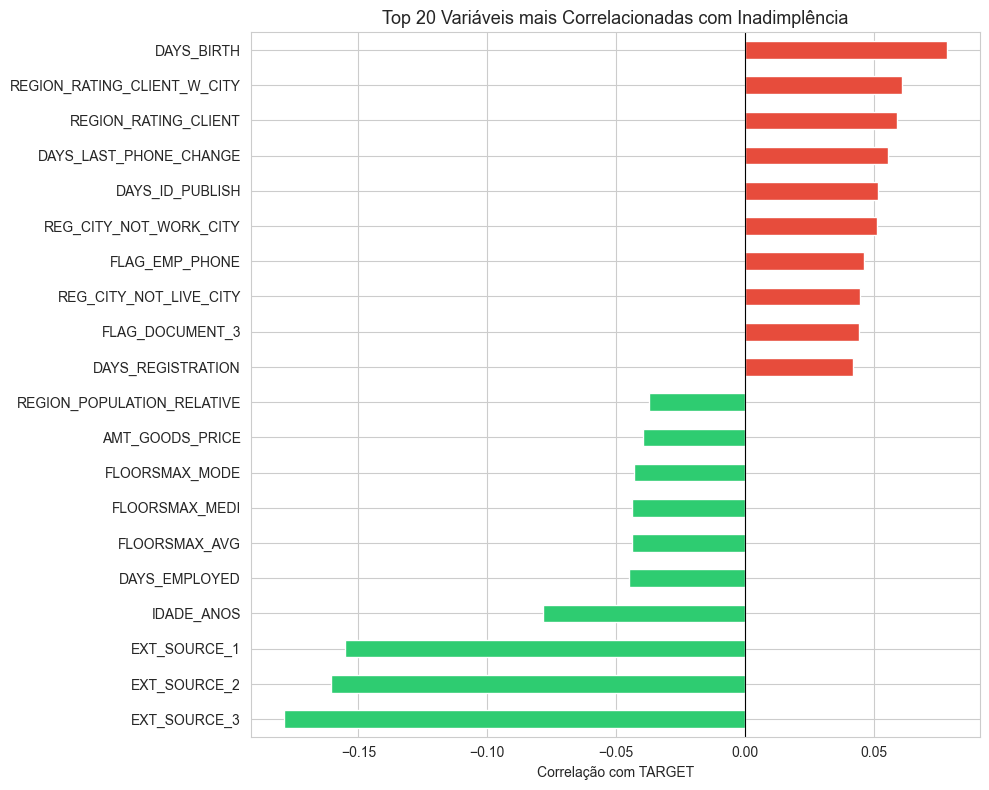

Maiores correlações POSITIVAS (aumentam risco):
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
Name: TARGET, dtype: float64

Maiores correlações NEGATIVAS (reduzem risco):
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
IDADE_ANOS                   -0.078237
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
Name: TARGET, dtype: float64


In [ ]:
# Selecionar apenas colunas numéricas
num_cols = df.select_dtypes(include=[np.number])

# Calcular correlação de cada variável com o TARGET
correlacoes = num_cols.corr()['TARGET'].drop('TARGET')

# Pegar as 10 mais positivas e 10 mais negativas
top_pos = correlacoes.sort_values(ascending=False).head(10)
top_neg = correlacoes.sort_values().head(10)
top_corr = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(10, 8))
cores = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
top_corr.plot(kind='barh', color=cores)
plt.title('Top 20 Variáveis mais Correlacionadas com Inadimplência', fontsize=13)
plt.xlabel('Correlação com TARGET')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Mostrar os valores
print("Maiores correlações POSITIVAS (aumentam risco):")
print(top_pos)
print("\nMaiores correlações NEGATIVAS (reduzem risco):")
print(top_neg)

### 6.6 Razão parcela/renda (debt-to-income)

Criação e análise de um indicador clássico de risco de crédito: a proporção da renda comprometida com a parcela.

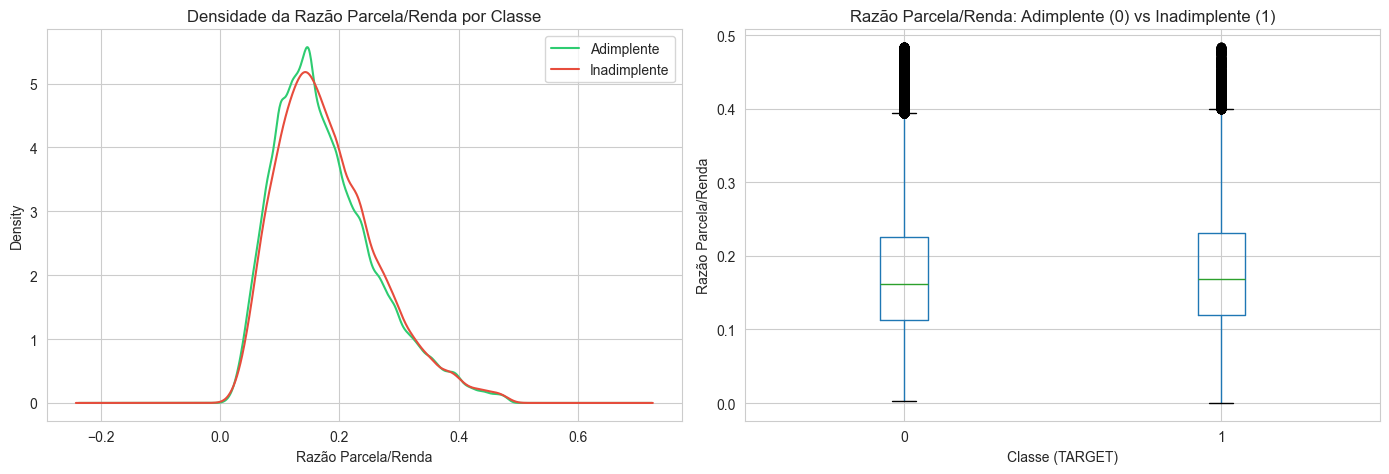

Razão Parcela/Renda média por classe:
TARGET
0    0.180530
1    0.185482
Name: RAZAO_PARCELA_RENDA, dtype: float64


In [ ]:
# Criar a feature: quanto da renda anual compromete com a parcela
df['RAZAO_PARCELA_RENDA'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Remover valores extremos para visualização (acima do percentil 99)
filtro_razao = df['RAZAO_PARCELA_RENDA'] < df['RAZAO_PARCELA_RENDA'].quantile(0.99)
df_viz = df[filtro_razao]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição da razão por classe
df_viz[df_viz['TARGET'] == 0]['RAZAO_PARCELA_RENDA'].plot(
    kind='kde', ax=axes[0], label='Adimplente', color='#2ecc71')
df_viz[df_viz['TARGET'] == 1]['RAZAO_PARCELA_RENDA'].plot(
    kind='kde', ax=axes[0], label='Inadimplente', color='#e74c3c')
axes[0].set_title('Densidade da Razão Parcela/Renda por Classe', fontsize=12)
axes[0].set_xlabel('Razão Parcela/Renda')
axes[0].legend()

# Boxplot comparando as classes
df_viz.boxplot(column='RAZAO_PARCELA_RENDA', by='TARGET', ax=axes[1])
axes[1].set_title('Razão Parcela/Renda: Adimplente (0) vs Inadimplente (1)', fontsize=12)
axes[1].set_xlabel('Classe (TARGET)')
axes[1].set_ylabel('Razão Parcela/Renda')
plt.suptitle('')  # remove título automático do pandas

plt.tight_layout()
plt.show()

# Comparar as médias
print("Razão Parcela/Renda média por classe:")
print(df.groupby('TARGET')['RAZAO_PARCELA_RENDA'].mean())

### 6.7 Detecção de outliers

Boxplots para visualização de valores extremos e da anomalia identificada em `DAYS_EMPLOYED`.

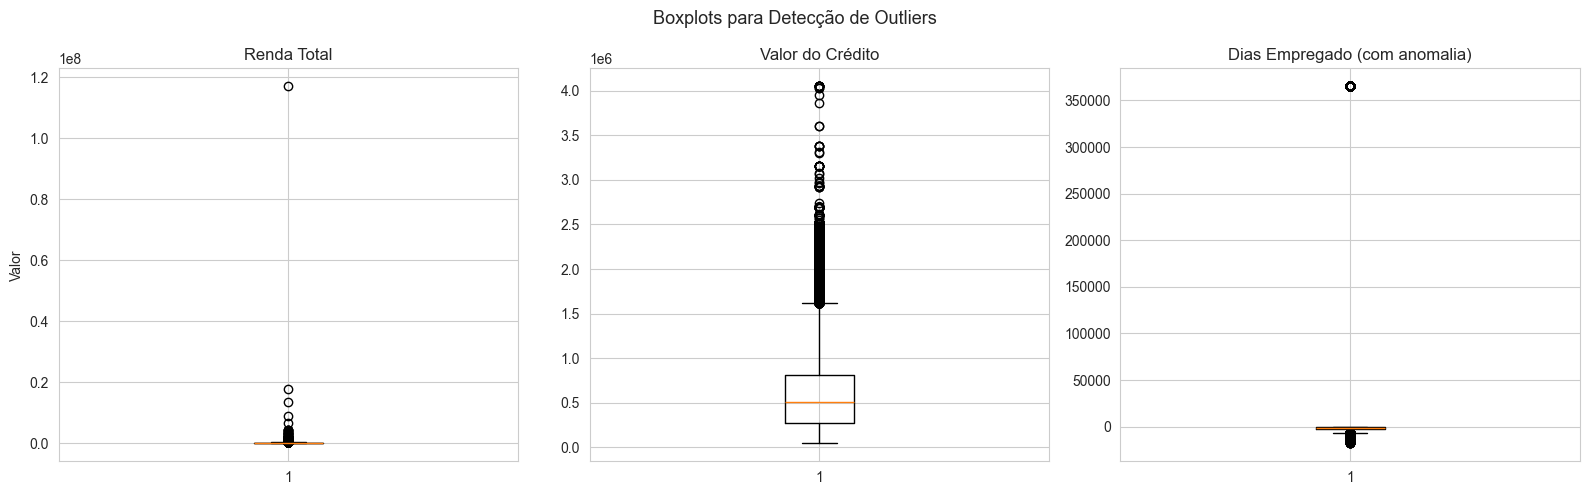

Valores únicos mais frequentes em DAYS_EMPLOYED (positivos = anomalia):
DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64

Total de registros com a anomalia (365243): 55374


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Renda total
axes[0].boxplot(df['AMT_INCOME_TOTAL'].dropna(), vert=True)
axes[0].set_title('Renda Total', fontsize=12)
axes[0].set_ylabel('Valor')

# Crédito
axes[1].boxplot(df['AMT_CREDIT'].dropna(), vert=True)
axes[1].set_title('Valor do Crédito', fontsize=12)

# DAYS_EMPLOYED (onde está a anomalia dos 1000 anos)
axes[2].boxplot(df['DAYS_EMPLOYED'].dropna(), vert=True)
axes[2].set_title('Dias Empregado (com anomalia)', fontsize=12)

plt.suptitle('Boxplots para Detecção de Outliers', fontsize=13)
plt.tight_layout()
plt.show()

# Confirmar a anomalia do DAYS_EMPLOYED
print("Valores únicos mais frequentes em DAYS_EMPLOYED (positivos = anomalia):")
print(df[df['DAYS_EMPLOYED'] > 0]['DAYS_EMPLOYED'].value_counts().head())
print(f"\nTotal de registros com a anomalia (365243): {(df['DAYS_EMPLOYED'] == 365243).sum()}")

### 6.8 Multicolinearidade entre features

Mapa de correlação entre as principais variáveis numéricas, identificando redundâncias relevantes para a modelagem.

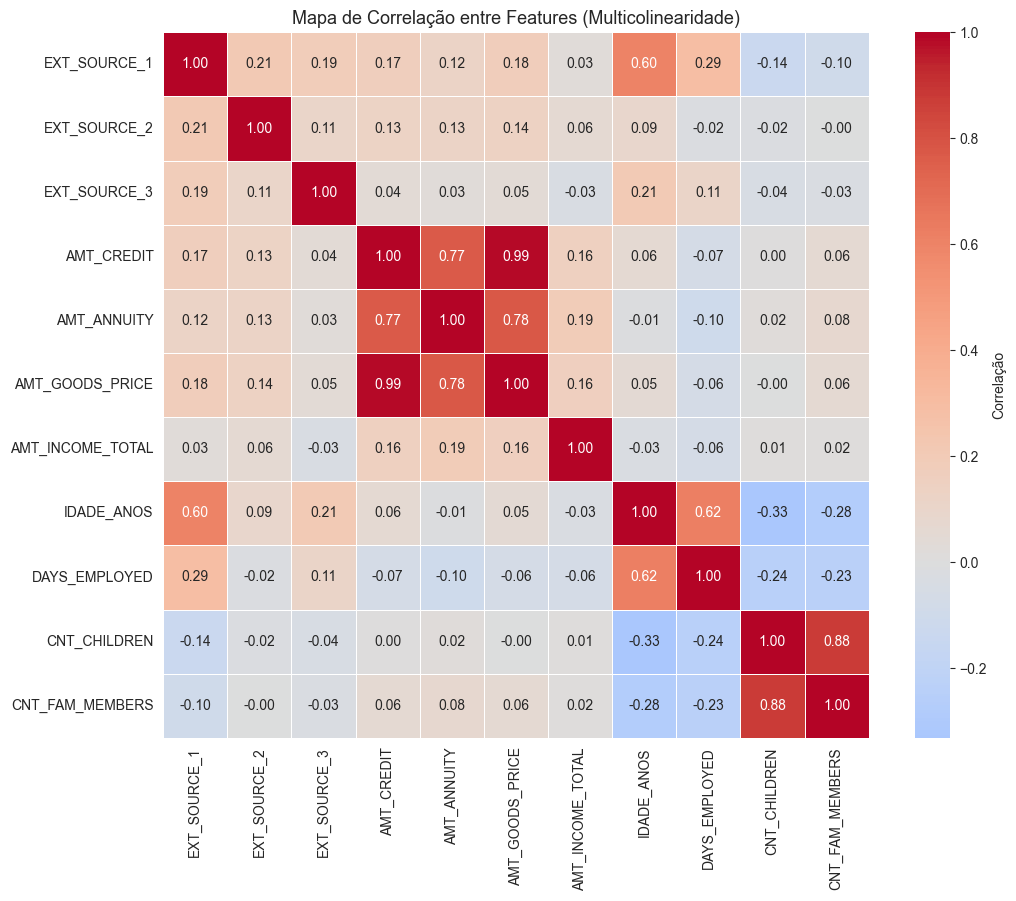

In [ ]:
# Selecionar variáveis relevantes para checar multicolinearidade
features_chave = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL',
    'IDADE_ANOS', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

# Calcular matriz de correlação
matriz_corr = df[features_chave].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlação'})
plt.title('Mapa de Correlação entre Features (Multicolinearidade)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Síntese e próximos passos

A EDA revelou: forte desbalanceamento (8% de inadimplentes), valores faltantes em 67 colunas, anomalia em `DAYS_EMPLOYED` (~18% dos registros), outliers de renda, multicolinearidade entre features, e as variáveis `EXT_SOURCE` como mais preditivas (convergindo com o benchmark).

**Próximas etapas:** pré-processamento (tratamento de faltantes e anomalias, SMOTE, padronização), seguido da modelagem com os cinco algoritmos e validação.